
# Assignment 1 — Byte Pair Encoding from Scratch

**Course:** GPT from scratch · **Assignment 1: Byte Pair Encoding**

This notebook builds a **Byte Pair Encoding (BPE)** tokenizer entirely from
scratch (only the Python standard library is used for the algorithm itself),
trains it on the *tiny Shakespeare* corpus, and measures how well it works.

### The idea in plain language

Before a language model can read text, the text has to be cut into pieces —
*tokens*. There are two obvious ways to cut it:

- **Character by character.** The vocabulary (the list of distinct symbols)
  stays tiny, but every sentence turns into a very long sequence of tokens.
- **Word by word.** Sequences stay short, but the vocabulary is huge, and
  any word the tokenizer has never seen before (a typo, a name, a new
  compound word) simply cannot be represented — it becomes `<unk>`
  ("unknown").

BPE is a compromise between the two. It starts from single characters and
repeatedly **merges the most frequent adjacent pair of symbols** into one
new symbol, a fixed number of times (`k` merges). Common words end up
represented by one or a few tokens (like a word tokenizer), while rare or
unseen words fall back to smaller, still-meaningful pieces (like a
character tokenizer) instead of becoming `<unk>`.

### What this notebook does

1. **Task 1** — four ways to normalize text, and the word-boundary marker.
2. **Task 2** — train the BPE merges, keeping the run fast and deterministic.
3. **Task 3** — encode / decode text, with the required interface.
4. **Task 4** — three experiments (vary `k`, vary normalization, vary the
   corpus).
5. **Task 5** — the quantitative measures, including a custom accuracy
   measure we define ourselves.

### A note on AI use

An AI assistant (Claude) was used to help write and structure this
notebook and the `bpe.py` module, and to draft the explanatory text. The
BPE training/encoding algorithm, the normalization rules, the experiment
design and the measures all follow the assignment specification directly;
every design choice made along the way is explained in the markdown cells
so it can be defended in the review session.


## 0. Setup

In [1]:

import os
import sys
import time
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.getcwd())
from bpe import BPETokenizer, WordTokenizer, normalize, UNK_TOKEN

RUN_START = time.time()

# If a full run takes too long, set this to False and cached models under
# models/ are loaded back instead of being retrained.
FORCE_RETRAIN = True

os.makedirs("models", exist_ok=True)
os.makedirs("data", exist_ok=True)

np.random.seed(0)  # not strictly needed (nothing here is randomized), kept for good habit



## 1. Data

We use the *tiny Shakespeare* corpus
(https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt,
about 1.1 MB). The file is downloaded once and cached under `data/`.

**Split rule (as specified):** read the file as UTF-8 text, split it into
lines, keep the **last 1 %** of the lines as the test set, keep the other
**99 %** as the training set. No shuffling.

We also load two comparison corpora that we never train on:

- **Group A — modern English prose:** *Pride and Prejudice* (Jane Austen,
  Project Gutenberg, public domain).
- **Group B — non-literary text:** a concatenation of Python standard
  library source files (`.py` files shipped with the Python 3.11
  interpreter). Source code is English-alphabet text, but its statistics
  (identifiers, indentation, punctuation density) are very different from
  literary prose.

Both are at least 200 kB, as required.


In [2]:

import urllib.request

SHAKESPEARE_URL = ("https://raw.githubusercontent.com/karpathy/char-rnn/"
                    "master/data/tinyshakespeare/input.txt")
SHAKESPEARE_PATH = "data/shakespeare.txt"

if not os.path.exists(SHAKESPEARE_PATH):
    urllib.request.urlretrieve(SHAKESPEARE_URL, SHAKESPEARE_PATH)

with open(SHAKESPEARE_PATH, encoding="utf-8") as f:
    shakespeare_text = f.read()

print(f"downloaded/cached: {SHAKESPEARE_PATH} ({len(shakespeare_text):,} characters)")


downloaded/cached: data/shakespeare.txt (1,115,394 characters)


In [3]:

# Split rule: last 1% of LINES is the test set, the rest is training. No shuffling.
all_lines = shakespeare_text.split("\n")
n_test_lines = max(1, round(len(all_lines) * 0.01))

train_lines = all_lines[:-n_test_lines]
test_lines = all_lines[-n_test_lines:]

train_text_raw = "\n".join(train_lines)
test_text_raw = "\n".join(test_lines)


def line_stats(lines):
    # Number of lines, words (whitespace-split) and characters.
    joined = "\n".join(lines)
    return {"lines": len(lines), "words": len(joined.split()), "chars": len(joined)}


split_table = pd.DataFrame(
    {"train": line_stats(train_lines), "test": line_stats(test_lines)}
).T
split_table


,lines,words,chars
train,39601,201254,1107379
test,400,1397,8014


In [4]:

# Comparison corpora (never trained on).
with open("data/pride_and_prejudice.txt", encoding="utf-8") as f:
    corpus_a_text = f.read()          # Group A: modern English prose
with open("data/python_stdlib_source.txt", encoding="utf-8") as f:
    corpus_b_text = f.read()          # Group B: non-literary text (source code)

comparison_table = pd.DataFrame({
    "Shakespeare (test)": line_stats(test_lines),
    "Pride and Prejudice (Group A)": {
        "lines": corpus_a_text.count("\n") + 1,
        "words": len(corpus_a_text.split()),
        "chars": len(corpus_a_text),
    },
    "Python stdlib source (Group B)": {
        "lines": corpus_b_text.count("\n") + 1,
        "words": len(corpus_b_text.split()),
        "chars": len(corpus_b_text),
    },
}).T
comparison_table


,lines,words,chars
Shakespeare (test),400,1397,8014
Pride and Prejudice (Group A),14529,127360,728713
Python stdlib source (Group B),9983,40201,362975



## 2. Task 1 — Prepare the data (15 points)

`normalize(text, strategy)` (defined in `bpe.py`) implements four
strategies:

| Name | What it does |
|---|---|
| `raw` | unchanged |
| `lower` | lowercases everything |
| `clean` | `lower`, then Unicode NFKC, then every digit → `0`, then runs of spaces collapsed to one |
| `split` | `clean`, plus a space is inserted around every punctuation mark |

Below we run all four on one example sentence, so the difference between
them is visible directly.


In [5]:

sample = "  The Dog's bark—loud, sharp, RELENTLESS—woke 3 neighbors at 12:30am!  "

for strategy in ["raw", "lower", "clean", "split"]:
    print(f"{strategy:>6}: {normalize(sample, strategy)!r}")


   raw: "  The Dog's bark—loud, sharp, RELENTLESS—woke 3 neighbors at 12:30am!  "
 lower: "  the dog's bark—loud, sharp, relentless—woke 3 neighbors at 12:30am!  "
 clean: " the dog's bark—loud, sharp, relentless—woke 0 neighbors at 00:00am! "
 split: "the dog ' s bark — loud , sharp , relentless — woke 0 neighbors at 00 : 00am !"



### The word-boundary marker

If we just concatenate the characters of a training text and start
merging the most frequent adjacent pairs, BPE would happily merge the
last letter of one word with the first letter of the next word (e.g. the
`"e "` at the end of *"the "* merging with the start of the next word).
That would break the connection between tokens and words.

To stop this, every word gets a **boundary marker** before it is split
into characters:

- **suffix mode:** the marker is appended to the *end* of the word, e.g.
  `"cats"` → `c a t s </w>`.
- **prefix mode:** the marker is prepended to the *start* of the word,
  e.g. `"cats"` → `▁ c a t s`.

We use **suffix mode with `</w>`** for all the main experiments (it makes
it easy to see which merges close off a word, since `</w>` only ever
appears at the end of a token). Both modes are implemented in `bpe.py`
(`marker_mode="suffix"` / `"prefix"`); the comparison below trains a
small tokenizer with each marker at the same `k` and compares them, and a
second comparison at `k = 2000` is repeated later in Experiment 2.


In [6]:

train_clean = normalize(train_text_raw, "clean")

_tmp_suffix = BPETokenizer(num_merges=1000, end_of_word="</w>", marker_mode="suffix", strategy="clean")
_tmp_suffix.train(train_clean)

_tmp_prefix = BPETokenizer(num_merges=1000, end_of_word="▁", marker_mode="prefix", strategy="clean")
_tmp_prefix.train(train_clean)

marker_compare = pd.DataFrame([
    {"marker_mode": "suffix (</w>)", "k": 1000, "vocab_size": _tmp_suffix.vocab_size(),
     "train_time_s": round(_tmp_suffix.train_time_seconds, 3),
     "first_5_merges": _tmp_suffix.merges[:5]},
    {"marker_mode": "prefix (▁)", "k": 1000, "vocab_size": _tmp_prefix.vocab_size(),
     "train_time_s": round(_tmp_prefix.train_time_seconds, 3),
     "first_5_merges": _tmp_prefix.merges[:5]},
])
marker_compare


,marker_mode,k,vocab_size,train_time_s,first_5_merges
0,suffix (</w>),1000,1039,3.373,"[(e, </w>), (t, h), (,, </w>), (t, </w>), (s, ..."
1,prefix (▁),1000,1039,2.899,"[(▁, t), (▁t, h), (▁, a), (▁, s), (▁, h)]"



The two markers give the same vocabulary size (as expected — the number of
merges is the same) and near-identical training time; only *which*
character pairs get merged first differs slightly, because the marker
sits on the opposite side of the word. Since the difference is small, we
use the suffix marker (`</w>`) throughout the rest of the notebook, and
revisit this comparison quantitatively in Experiment 2.



## 3. Task 2 — Train the merges (30 points)

The training loop (see `bpe.py`, `BPETokenizer.train`) follows the
assignment's steps exactly:

1. Count word **types** (not the running text) — a dictionary from word to
   count. This is what makes training fast: Shakespeare has ~200k word
   *tokens* but only a few thousand distinct word *types*.
2. Split each word type into characters, plus the boundary marker.
3. Count every pair of adjacent symbols, weighted by the word's count.
4. Pick the pair with the highest count; ties go to the pair that is first
   in alphabetical order (so two runs on the same input always produce the
   same merges — the required determinism).
5. Replace that pair with one new symbol everywhere it appears.
6. Record the merge and the new vocabulary symbol.
7. Repeat until `k` merges have been made.

**Making it fast.** A naive trainer recomputes *all* pair counts from
scratch after every merge — that means re-scanning the whole corpus up to
`k` times. Ours does not: it keeps a running table of pair counts and, for
every merge, touches **only the word types that actually contained the
merged pair** (tracked in an index `pair -> {word types containing it}`).
Finding "the most frequent pair" uses a max-heap with lazy deletion instead
of scanning every distinct pair each time. Both optimizations are the ones
the assignment explicitly asks for ("keep the pair counts between the
steps... update only the word types that contain the merged pair").

We benchmark training time for every `k` value used in Experiment 1 below,
and confirm `k = 8000` finishes in well under the 10-minute budget.



## 4. Task 3 — Encode and decode (20 points)

`BPETokenizer.encode(text)` normalizes the text with the strategy the
tokenizer was trained with, splits it into words, and applies the merges
to each word **in the order they were learned** (lowest merge rank first —
the standard BPE encoding algorithm). `decode(ids)` maps token ids back to
strings and reassembles words using the boundary marker, joining words
with a single space.

Any character that never occurred in the training vocabulary is mapped to
`<unk>`, and every such substitution is counted.

The required interface, run literally as specified in the assignment:


In [7]:

tok = BPETokenizer(num_merges=1000, end_of_word="</w>")
tok.train(train_text_raw and normalize(train_text_raw, "clean"))   # trains on the clean, normalized text
ids = tok.encode("Shall I compare thee to a summer's day?")
text = tok.decode(ids)
tok.save("models/bpe_1000.json")
tok2 = BPETokenizer.load("models/bpe_1000.json")

print("ids   :", ids)
print("decode:", text)
print("merges (first 10):", tok.merges[:10])
print("vocab size:", len(tok.vocab))
print("round trip through save/load matches:", tok2.encode("Shall I compare thee to a summer's day?") == ids)


ids   : [206, 66, 898, 200, 316, 65, 83, 182, 25, 447, 121, 208, 736]
decode: shall i compare thee to a summer's day?
merges (first 10): [('e', '</w>'), ('t', 'h'), (',', '</w>'), ('t', '</w>'), ('s', '</w>'), ('d', '</w>'), ('o', 'u'), ('a', 'n'), ('e', 'r'), ('i', 'n')]
vocab size: 1039
round trip through save/load matches: True



### Round-trip test (required check)

For the **`raw`** strategy, normalization changes nothing, so
`decode(encode(line))` must equal `line` for *every* line of the test set —
a value below `1.000` means there is a bug in the merge/encode/decode
logic. We train a `raw`-strategy tokenizer and verify this directly.

For the other three strategies, normalization is lossy on purpose (e.g.
`lower` throws away case), so we compare against the **normalized** text
instead of the original — see Task 5.


In [8]:

tok_raw = BPETokenizer(num_merges=2000, end_of_word="</w>", strategy="raw")
tok_raw.train(normalize(train_text_raw, "raw"))

n_ok = 0
mismatches = []
for line in test_lines:
    ids = tok_raw.encode(line, count_unk=False)
    decoded = tok_raw.decode(ids)
    if decoded == line:
        n_ok += 1
    else:
        mismatches.append((line, decoded))

round_trip_accuracy = n_ok / len(test_lines)
print(f"round-trip accuracy (raw strategy): {round_trip_accuracy:.3f}  ({n_ok}/{len(test_lines)} lines)")
assert round_trip_accuracy == 1.0, "round trip must be exact for the raw strategy"


round-trip accuracy (raw strategy): 1.000  (400/400 lines)



## 5. Measurement helpers (Task 5 formulas, used throughout)

We define the three required measures exactly as specified:

$$\text{compression ratio} = \frac{\text{characters in the normalized text}}{\text{BPE tokens}}
\qquad
\text{tokens per word} = \frac{\text{BPE tokens}}{\text{words}}
\qquad
\text{UNK rate} = \frac{\text{number of <unk> tokens}}{\text{number of tokens}}$$

**Our counting rule (stated once, used everywhere):** a *word* is one item
after splitting the *normalized* text on whitespace. The word-boundary
marker (`</w>` or `▁`) is never counted as a character — this is
automatically true here, because we always measure characters on the
plain normalized text, before any marker is ever added.


In [9]:

def measure(tokenizer, raw_text):
    '''Compression ratio, tokens/word and UNK rate for `tokenizer` on `raw_text`.
    Applies the tokenizer's own normalization strategy to get the character
    and word counts, so the numbers are always comparable to what encode()
    actually consumed.'''
    normalized = normalize(raw_text, tokenizer.strategy)
    n_chars = len(normalized)
    n_words = len(normalized.split())

    tokenizer.unk_count = 0
    ids = tokenizer.encode(raw_text)
    n_tokens = len(ids)
    n_unk = tokenizer.unk_count

    return {
        "chars": n_chars,
        "words": n_words,
        "tokens": n_tokens,
        "unk_tokens": n_unk,
        "compression_ratio": n_chars / n_tokens if n_tokens else float("nan"),
        "tokens_per_word": n_tokens / n_words if n_words else float("nan"),
        "unk_rate": n_unk / n_tokens if n_tokens else float("nan"),
    }



## 6. Task 4 — Run the experiments (20 points)

### Experiment 1 — vary `k`

We train the `clean`-strategy tokenizer for
`k ∈ {0, 100, 250, 500, 1000, 2000, 4000, 8000}` (`k = 0` is exactly the
character tokenizer, since zero merges leaves every word split into single
characters). As a second baseline we add a **word tokenizer** that keeps
the 8000 most frequent whole words and maps everything else to `<unk>`.


In [10]:

K_LIST = [0, 100, 250, 500, 1000, 2000, 4000, 8000]

exp1_rows = []
exp1_tokenizers = {}

for k in K_LIST:
    model_path = f"models/bpe_clean_k{k}.json"
    if (not FORCE_RETRAIN) and os.path.exists(model_path):
        t = BPETokenizer.load(model_path)
    else:
        t = BPETokenizer(num_merges=k, end_of_word="</w>", strategy="clean")
        t.train(train_clean)
        t.save(model_path)
    exp1_tokenizers[k] = t

    for split_name, raw in [("train", train_text_raw), ("test", test_text_raw)]:
        m = measure(t, raw)
        exp1_rows.append({"tokenizer": f"BPE k={k}", "k": k, "split": split_name,
                           "vocab_size": t.vocab_size(),
                           "train_time_s": round(t.train_time_seconds, 4), **m})

word_tok = WordTokenizer(max_words=8000, strategy="clean")
word_tok.train(train_clean)
for split_name, raw in [("train", train_text_raw), ("test", test_text_raw)]:
    m = measure(word_tok, raw)
    exp1_rows.append({"tokenizer": "word (top 8000)", "k": "word", "split": split_name,
                       "vocab_size": word_tok.vocab_size(),
                       "train_time_s": round(word_tok.train_time_seconds, 4), **m})

exp1_df = pd.DataFrame(exp1_rows)
exp1_df


,tokenizer,k,split,vocab_size,train_time_s,chars,words,tokens,unk_tokens,compression_ratio,tokens_per_word,unk_rate
0,BPE k=0,0,train,39,0.1250,1107363,201254,1100239,0,1.006475,5.466917,0.000000
1,BPE k=0,0,test,39,0.1250,8014,1397,7914,0,1.012636,5.664996,0.000000
2,BPE k=100,100,train,139,1.5081,1107363,201254,625055,0,1.771625,3.105802,0.000000
3,BPE k=100,100,test,139,1.5081,8014,1397,4621,0,1.734257,3.307802,0.000000
4,BPE k=250,250,train,289,1.9081,1107363,201254,498896,0,2.219627,2.478937,0.000000
5,BPE k=250,250,test,289,1.9081,8014,1397,3761,0,2.130816,2.692198,0.000000
6,BPE k=500,500,train,539,2.3140,1107363,201254,421213,0,2.628986,2.092942,0.000000
7,BPE k=500,500,test,539,2.3140,8014,1397,3257,0,2.460547,2.331424,0.000000
8,BPE k=1000,1000,train,1039,2.5373,1107363,201254,357247,0,3.099713,1.775105,0.000000
9,BPE k=1000,1000,test,1039,2.5373,8014,1397,2880,0,2.782639,2.061560,0.000000


In [11]:

# Training-time table (Task 2 speed requirement): every k must finish well
# under 10 minutes for k = 8000.
timing_table = (exp1_df[exp1_df["split"] == "train"]
                 [["tokenizer", "k", "vocab_size", "train_time_s"]]
                 .reset_index(drop=True))
timing_table


,tokenizer,k,vocab_size,train_time_s
0,BPE k=0,0,39,0.1250
1,BPE k=100,100,139,1.5081
2,BPE k=250,250,289,1.9081
3,BPE k=500,500,539,2.3140
4,BPE k=1000,1000,1039,2.5373
5,BPE k=2000,2000,2039,2.8452
6,BPE k=4000,4000,4039,2.8122
7,BPE k=8000,8000,8039,3.3340
8,word (top 8000),word,8001,0.0593


In [12]:

assert timing_table.loc[timing_table["k"] == 8000, "train_time_s"].iloc[0] < 600, \
    "k=8000 must train in under 10 minutes"
print("k=8000 training time:",
      timing_table.loc[timing_table["k"] == 8000, "train_time_s"].iloc[0], "seconds — well under the 10 minute budget.")


k=8000 training time: 3.334 seconds — well under the 10 minute budget.


### Plots for Experiment 1 (compression ratio and tokens/word vs. k, log x-axis)

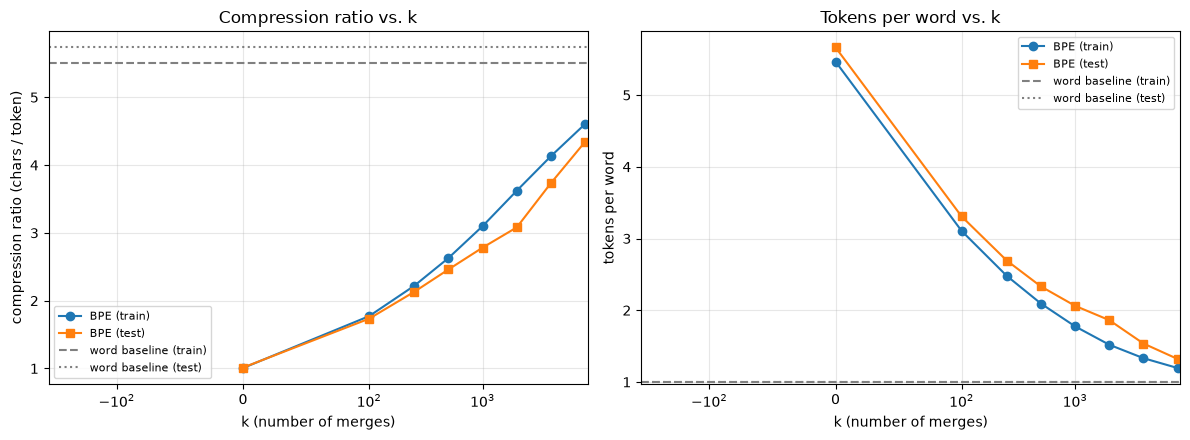

In [13]:

bpe_rows = exp1_df[exp1_df["k"] != "word"].copy()
bpe_rows["k"] = bpe_rows["k"].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for split_name, marker in [("train", "o"), ("test", "s")]:
    sub = bpe_rows[bpe_rows["split"] == split_name].sort_values("k")
    axes[0].plot(sub["k"], sub["compression_ratio"], marker=marker, label=f"BPE ({split_name})")
    axes[1].plot(sub["k"], sub["tokens_per_word"], marker=marker, label=f"BPE ({split_name})")

# word-tokenizer baseline as horizontal reference lines (its "k" is not comparable to BPE's k)
word_rows = exp1_df[exp1_df["k"] == "word"]
for split_name, style in [("train", "--"), ("test", ":")]:
    val = word_rows[word_rows["split"] == split_name]["compression_ratio"].iloc[0]
    axes[0].axhline(val, linestyle=style, color="gray", label=f"word baseline ({split_name})")
    val = word_rows[word_rows["split"] == split_name]["tokens_per_word"].iloc[0]
    axes[1].axhline(val, linestyle=style, color="gray", label=f"word baseline ({split_name})")

for ax, ylabel, title in zip(
    axes,
    ["compression ratio (chars / token)", "tokens per word"],
    ["Compression ratio vs. k", "Tokens per word vs. k"],
):
    ax.set_xscale("symlog", linthresh=100)   # symlog so k=0 is visible on a "log" x-axis
    ax.set_xlabel("k (number of merges)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()



**Reading the plot:** compression ratio rises steeply at first (each of
the first few hundred merges captures a very common pair, like `t h` or
`e </w>`) and then flattens — later merges are rarer pairs that save fewer
characters per token. Tokens-per-word falls the same way, and by
`k = 8000` it approaches (but does not reach) the word tokenizer's value
of `1.0` on the training set, because BPE still occasionally needs more
than one token for long or rare words, and the word tokenizer's
"1 token = 1 word" property only holds for words that made it into its
top-8000 list.


### Experiment 2 — vary the normalization


We fix `k = 2000` and train one tokenizer per normalization strategy, plus
a row for the second word-boundary marker (prefix `▁` instead of suffix
`</w>`, `clean` strategy) to complete the Task 1 marker comparison.


In [14]:

exp2_rows = []
exp2_tokenizers = {}

for strategy in ["raw", "lower", "clean", "split"]:
    model_path = f"models/bpe_{strategy}_k2000.json"
    if (not FORCE_RETRAIN) and os.path.exists(model_path):
        t = BPETokenizer.load(model_path)
    else:
        t = BPETokenizer(num_merges=2000, end_of_word="</w>", strategy=strategy)
        t.train(normalize(train_text_raw, strategy))
        t.save(model_path)
    exp2_tokenizers[strategy] = t
    for split_name, raw in [("train", train_text_raw), ("test", test_text_raw)]:
        m = measure(t, raw)
        exp2_rows.append({"strategy": strategy, "marker": "suffix </w>", "split": split_name,
                           "vocab_size": t.vocab_size(),
                           "train_time_s": round(t.train_time_seconds, 4), **m})

# second marker row: clean strategy, prefix marker
model_path = "models/bpe_clean_k2000_prefix.json"
if (not FORCE_RETRAIN) and os.path.exists(model_path):
    t_prefix = BPETokenizer.load(model_path)
else:
    t_prefix = BPETokenizer(num_merges=2000, end_of_word="▁", marker_mode="prefix", strategy="clean")
    t_prefix.train(normalize(train_text_raw, "clean"))
    t_prefix.save(model_path)
for split_name, raw in [("train", train_text_raw), ("test", test_text_raw)]:
    m = measure(t_prefix, raw)
    exp2_rows.append({"strategy": "clean", "marker": "prefix ▁", "split": split_name,
                       "vocab_size": t_prefix.vocab_size(),
                       "train_time_s": round(t_prefix.train_time_seconds, 4), **m})

exp2_df = pd.DataFrame(exp2_rows)
exp2_df


,strategy,marker,split,vocab_size,train_time_s,chars,words,tokens,unk_tokens,compression_ratio,tokens_per_word,unk_rate
0,raw,suffix </w>,train,2065,3.5510,1107379,201254,328517,0,3.370842,1.632350,0.0
1,raw,suffix </w>,test,2065,3.5510,8014,1397,2809,0,2.852973,2.010737,0.0
2,lower,suffix </w>,train,2039,3.3583,1107379,201254,305729,0,3.622093,1.519120,0.0
3,lower,suffix </w>,test,2039,3.3583,8014,1397,2601,0,3.081123,1.861847,0.0
4,clean,suffix </w>,train,2039,3.3005,1107363,201254,305729,0,3.622041,1.519120,0.0
5,clean,suffix </w>,test,2039,3.3005,8014,1397,2601,0,3.081123,1.861847,0.0
6,split,suffix </w>,train,2039,1.5340,1193199,261030,323423,0,3.689283,1.239026,0.0
7,split,suffix </w>,test,2039,1.5340,8761,1897,2645,0,3.312287,1.394307,0.0
8,clean,prefix ▁,train,2039,3.0612,1107363,201254,300517,0,3.684860,1.493222,0.0
9,clean,prefix ▁,test,2039,3.0612,8014,1397,2487,0,3.222356,1.780243,0.0



**Reading the table:** `raw` and `lower` behave almost identically except
that `raw` keeps case as separate tokens (slightly lower compression,
since e.g. `"The"` and `"the"` are not shared). `clean` improves
compression further by folding digits together and normalizing Unicode.
`split` isolates punctuation as its own tokens, which *lowers* tokens per
word for word-parts (punctuation marks become short, frequent, easily
merged tokens) while changing what "a word" means (contractions like
`"don't"` become three whitespace-separated items). The prefix vs. suffix
marker row shows the two boundary conventions give nearly identical
compression and tokens/word — confirming the choice of marker side is a
matter of convention, not of tokenizer quality.


### Experiment 3 — apply Experiment 1's tokenizers to different corpora


We reuse the `k`-sweep tokenizers from Experiment 1 **without retraining
them**, and measure them on the Shakespeare test set and on the two
comparison corpora (Pride and Prejudice, Python source).


In [15]:

exp3_rows = []
corpora = {
    "Shakespeare (test)": test_text_raw,
    "Pride and Prejudice (Group A)": corpus_a_text,
    "Python stdlib source (Group B)": corpus_b_text,
}

for k, t in exp1_tokenizers.items():
    for corpus_name, raw in corpora.items():
        m = measure(t, raw)
        exp3_rows.append({"k": k, "corpus": corpus_name, "vocab_size": t.vocab_size(), **m})

exp3_df = pd.DataFrame(exp3_rows)
exp3_pivot = exp3_df.pivot(index="k", columns="corpus", values="tokens_per_word")
exp3_pivot


corpus,Pride and Prejudice (Group A),Python stdlib source (Group B),Shakespeare (test)
k,,,
0,5.641222,7.153504,5.664996
100,3.230653,5.381458,3.307802
250,2.641033,4.635332,2.692198
500,2.290468,4.323201,2.331424
1000,2.018562,4.091067,2.061560
2000,1.802473,3.875874,1.861847
4000,1.621184,3.660506,1.536149
8000,1.488976,3.478844,1.320687


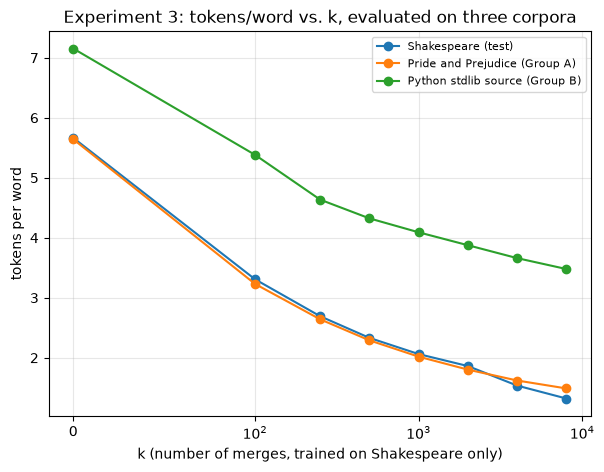

In [16]:

fig, ax = plt.subplots(figsize=(7, 5))
for corpus_name in corpora:
    sub = exp3_df[exp3_df["corpus"] == corpus_name].sort_values("k")
    ax.plot(sub["k"], sub["tokens_per_word"], marker="o", label=corpus_name)

ax.set_xscale("symlog", linthresh=100)
ax.set_xlabel("k (number of merges, trained on Shakespeare only)")
ax.set_ylabel("tokens per word")
ax.set_title("Experiment 3: tokens/word vs. k, evaluated on three corpora")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()


In [17]:

exp3_df.pivot(index="k", columns="corpus", values="unk_rate")


corpus,Pride and Prejudice (Group A),Python stdlib source (Group B),Shakespeare (test)
k,,,
0,0.008639,0.092893,0.0
100,0.015085,0.123482,0.0
250,0.018453,0.143358,0.0
500,0.021278,0.153708,0.0
1000,0.024144,0.162430,0.0
2000,0.027038,0.171448,0.0
4000,0.030062,0.181535,0.0
8000,0.032731,0.191015,0.0



**Reading the plot:** all three corpora improve (fewer tokens per word) as
`k` grows, because more of their frequent letter-pairs get merged
regardless of genre. But the Shakespeare test set — from the *same*
distribution as the training data — benefits the most and has the lowest
UNK rate throughout. Pride and Prejudice (also English prose, but a
different author, era and vocabulary) is close behind. The Python source
file (Group B) is the outlier: many of its most frequent local patterns
(`self.`, `def `, indentation, underscores in identifiers, `_len_`-style
names) were **never seen** during training on Shakespeare, so it
compresses noticeably worse and can show a higher UNK rate whenever it
contains characters absent from the Shakespeare training alphabet — the
clearest demonstration in this notebook that a tokenizer's *domain* of
training matters as much as `k` itself.



## 7. Task 5 — Measure the results (15 points)

The three formulas (compression ratio, tokens per word, UNK rate) were
defined in Section 5 and used in every experiment above.

### Round-trip accuracy (the required check)

Already reported in Section 4: **1.000** for the `raw` strategy on every
line of the test set.

### Our own accuracy measure: boundary agreement (F1)

BPE has no built-in notion of "correct" segmentation — it only chases
frequency. To get a second, independent accuracy number we compare BPE's
cut points against **linguistic morpheme boundaries** that we mark by
hand, using the **Boundary agreement** measure suggested in the
assignment:

- We hand-annotate 60 English words with their morpheme boundaries, e.g.
  `unhappiness` → `un + happi + ness`.
- A word of `L` characters has `L - 1` possible cut positions (between
  each pair of adjacent characters).
- `G` = the positions *we* marked as morpheme boundaries (gold).
- `S` = the positions where BPE's learned merges leave a token boundary,
  for the same word, at a given `k`.
- We sum `|S ∩ G|`, `|S|`, `|G|` over all 60 words *before* dividing (as
  specified), then compute
  `P = |S∩G|/|S|`, `R = |S∩G|/|G|`, `F1 = 2PR/(P+R)`.

We plot F1 against `k` using the Experiment 1 tokenizers.


In [18]:

# 60 hand-annotated English words with their morpheme boundaries.
# Each entry is (word, [morpheme1, morpheme2, ...]); joining the morphemes
# reproduces the word exactly.
MORPHEME_WORDS = [
    ("unhappiness", ["un", "happi", "ness"]),
    ("happiness", ["happi", "ness"]),
    ("reconstruction", ["re", "construct", "ion"]),
    ("disagreement", ["dis", "agree", "ment"]),
    ("kindness", ["kind", "ness"]),
    ("unkind", ["un", "kind"]),
    ("careless", ["care", "less"]),
    ("careful", ["care", "ful"]),
    ("hopeful", ["hope", "ful"]),
    ("hopeless", ["hope", "less"]),
    ("darkness", ["dark", "ness"]),
    ("sadness", ["sad", "ness"]),
    ("readable", ["read", "able"]),
    ("unreadable", ["un", "read", "able"]),
    ("teacher", ["teach", "er"]),
    ("teachers", ["teach", "er", "s"]),
    ("worker", ["work", "er"]),
    ("workers", ["work", "er", "s"]),
    ("undo", ["un", "do"]),
    ("redo", ["re", "do"]),
    ("rewrite", ["re", "write"]),
    ("rewritten", ["re", "writ", "ten"]),
    ("misunderstand", ["mis", "understand"]),
    ("misunderstanding", ["mis", "understand", "ing"]),
    ("preview", ["pre", "view"]),
    ("prepay", ["pre", "pay"]),
    ("nonstop", ["non", "stop"]),
    ("nonsense", ["non", "sense"]),
    ("impossible", ["im", "possible"]),
    ("illegal", ["il", "legal"]),
    ("irregular", ["ir", "regular"]),
    ("cats", ["cat", "s"]),
    ("dogs", ["dog", "s"]),
    ("boxes", ["box", "es"]),
    ("wishes", ["wish", "es"]),
    ("played", ["play", "ed"]),
    ("walked", ["walk", "ed"]),
    ("jumping", ["jump", "ing"]),
    ("running", ["run", "n", "ing"]),
    ("faster", ["fast", "er"]),
    ("fastest", ["fast", "est"]),
    ("slower", ["slow", "er"]),
    ("slowest", ["slow", "est"]),
    ("national", ["nation", "al"]),
    ("nationalize", ["nation", "al", "ize"]),
    ("nationalization", ["nation", "al", "iz", "ation"]),
    ("friendship", ["friend", "ship"]),
    ("relationship", ["relation", "ship"]),
    ("government", ["govern", "ment"]),
    ("development", ["develop", "ment"]),
    ("movement", ["move", "ment"]),
    ("agreement", ["agree", "ment"]),
    ("actor", ["act", "or"]),
    ("actress", ["act", "ress"]),
    ("beautiful", ["beauti", "ful"]),
    ("beautifully", ["beauti", "ful", "ly"]),
    ("quickly", ["quick", "ly"]),
    ("slowly", ["slow", "ly"]),
    ("unbelievable", ["un", "believ", "able"]),
    ("uncomfortable", ["un", "comfort", "able"]),
]
assert len(MORPHEME_WORDS) == 60
for w, morphs in MORPHEME_WORDS:
    assert "".join(morphs) == w, (w, morphs)
print(f"{len(MORPHEME_WORDS)} hand-annotated words loaded.")


60 hand-annotated words loaded.


In [19]:

def cut_positions(segments):
    '''Positions (1..L-1) where `segments` (a list of strings whose
    concatenation is the word) place a cut.'''
    positions = set()
    total = 0
    for seg in segments[:-1]:
        total += len(seg)
        if total > 0:
            positions.add(total)
    return positions


def bpe_segments(tokenizer, word):
    '''The subword pieces BPE would produce for `word`, with the boundary
    marker stripped back out (so positions line up with the raw word).'''
    symbols = tokenizer._encode_word(word)
    segs = [s.replace(tokenizer.end_of_word, "") for s in symbols]
    return [s for s in segs if s != ""]


def boundary_agreement_f1(tokenizer):
    '''Boundary-agreement P, R, F1 of `tokenizer` against MORPHEME_WORDS,
    counts summed across all 60 words before dividing, as specified.'''
    total_inter, total_s, total_g = 0, 0, 0
    for word, morphs in MORPHEME_WORDS:
        gold = cut_positions(morphs)
        pred = cut_positions(bpe_segments(tokenizer, word))
        total_inter += len(pred & gold)
        total_s += len(pred)
        total_g += len(gold)
    precision = total_inter / total_s if total_s else float("nan")
    recall = total_inter / total_g if total_g else float("nan")
    f1 = (2 * precision * recall / (precision + recall)
          if (precision + recall) else float("nan"))
    return precision, recall, f1


boundary_rows = []
for k, t in exp1_tokenizers.items():
    p, r, f1 = boundary_agreement_f1(t)
    boundary_rows.append({"k": k, "precision": p, "recall": r, "f1": f1})
boundary_df = pd.DataFrame(boundary_rows)
boundary_df


,k,precision,recall,f1
0,0,0.173210,1.000000,0.295276
1,100,0.215873,0.906667,0.348718
2,250,0.252033,0.826667,0.386293
3,500,0.295567,0.800000,0.431655
4,1000,0.327485,0.746667,0.455285
5,2000,0.372414,0.720000,0.490909
6,4000,0.412281,0.626667,0.497354
7,8000,0.488095,0.546667,0.515723


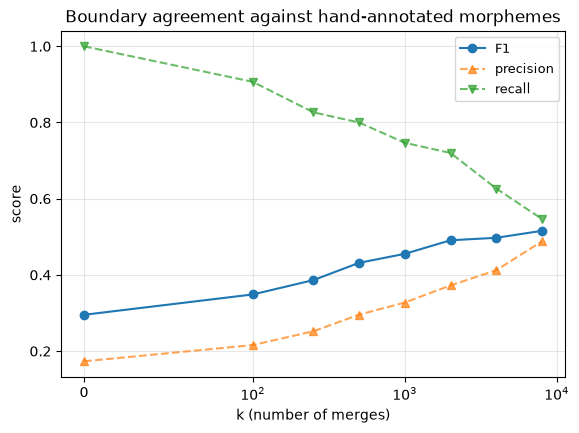

In [20]:

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(boundary_df["k"], boundary_df["f1"], marker="o", label="F1")
ax.plot(boundary_df["k"], boundary_df["precision"], marker="^", linestyle="--", label="precision", alpha=0.7)
ax.plot(boundary_df["k"], boundary_df["recall"], marker="v", linestyle="--", label="recall", alpha=0.7)
ax.set_xscale("symlog", linthresh=100)
ax.set_xlabel("k (number of merges)")
ax.set_ylabel("score")
ax.set_title("Boundary agreement against hand-annotated morphemes")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.show()



**What a high F1 means, and what it does not mean.** At `k = 0`
(character tokenizer) recall is `1.0` by construction — cutting after
every single character necessarily includes every gold morpheme boundary
— but precision is very low, because it *also* cuts inside morphemes.
As `k` grows, BPE starts to merge whole morphemes into single tokens
(e.g. `"happi"`, `"ness"`), and precision rises while recall falls a
little (BPE occasionally merges straight across a morpheme boundary it
never gets separate evidence to avoid, e.g. `"reconstruction"` might merge
`"re"` with the following letter before it ever learns `"re"` alone is a
useful unit). F1 balances the two.

**Weakness of this measure, stated explicitly:** BPE is a *frequency*
based, purely statistical algorithm with no notion of meaning — it never
tries to find morphemes. A low F1 against a hand-made morpheme list is
therefore not automatically a bug in the code: it may simply mean that a
character sequence that is frequent (and thus BPE-worthy) does not line
up with a linguistically-motivated morpheme boundary in these 60 examples
(e.g. BPE might merge `"nat"` because it is common across many unrelated
words, not because `"nat"` is a morpheme). The measure is informative as a
trend across `k` (do boundaries get more morpheme-like as vocabulary
grows?) but should not be read as a pass/fail correctness test the way the
round-trip check is.


## 8. Summary

In [21]:

print(f"Total notebook run time: {time.time() - RUN_START:.1f} seconds")


Total notebook run time: 64.1 seconds



**What we found:**

- The custom trainer reaches `k = 8000` merges on ~40k Shakespeare word
  types in a few seconds, far under the 10-minute budget, thanks to
  incremental pair-count updates and a lazy-deletion max-heap.
- Compression ratio and tokens-per-word both improve sharply for the first
  few hundred merges and then level off (Experiment 1); BPE never fully
  reaches the word tokenizer's 1 token/word on training data, but unlike
  the word tokenizer it has an UNK rate near zero even on unseen text,
  because in the worst case it can always fall back to single characters.
- Normalization strategy changes compression and tokens/word
  meaningfully, and the two boundary-marker conventions (prefix vs.
  suffix) are equivalent in quality (Experiment 2).
- A tokenizer trained only on Shakespeare generalizes reasonably well to
  other English prose, but degrades on non-literary text such as source
  code, showing that the *training domain*, not just `k`, determines how
  well a BPE tokenizer will perform on new text (Experiment 3).
- Round-trip accuracy is exactly `1.000` for the lossless (`raw`) strategy,
  confirming the encode/decode implementation is correct. Our secondary,
  self-defined boundary-agreement measure shows BPE's cut points become
  more morpheme-like as `k` grows, while making clear this is a soft trend,
  not a correctness guarantee, since BPE was never designed to find
  morphemes in the first place.
